# Clustering for claim size in order to set a large loss threshold

Firstly, we filter the data to only look at datapoints where a claim happened. We then check that we only deal with positive claim (which we do), and then we filter the house variables which we want to cluster on.

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

data_mice_encoded = pd.read_csv("data_mice_encoded.csv")

data_claim1 = data_mice_encoded[
    data_mice_encoded['CLAIM_COUNT'] == 1
].copy()

print(data_claim1['CLAIM_SIZE_INDEX'].describe())
print("Number of CLAIM_SIZE_INDEX <= 0:", (data_claim1['CLAIM_SIZE_INDEX'] <= 0).sum())


house_vars = [
    c for c in data_claim1.columns
    if c not in [
        'POLICY',
        'YEAR',
        'EXPOSURE',
        'CLAIM_COUNT',
        'CLAIM_SIZE',
        'CLAIM_SIZE_INDEX',
        'DEDUCTIBLE',
        'ROOF_TYPE',
        'WATER_SUPPLY_TYPE',
        'HEATING_TYPE',
        'OUTER_WALLS'
    ]
]

count    4.987000e+03
mean     5.513286e+04
std      2.897989e+05
min      4.423237e+01
25%      2.341259e+03
50%      5.543406e+03
75%      1.624918e+04
max      7.120126e+06
Name: CLAIM_SIZE_INDEX, dtype: float64
Number of CLAIM_SIZE_INDEX <= 0: 0


### PCA 

We now check the PCA to see if we get two groups. We furthermore color them depending on their claimsize to check if anything systematic happens.

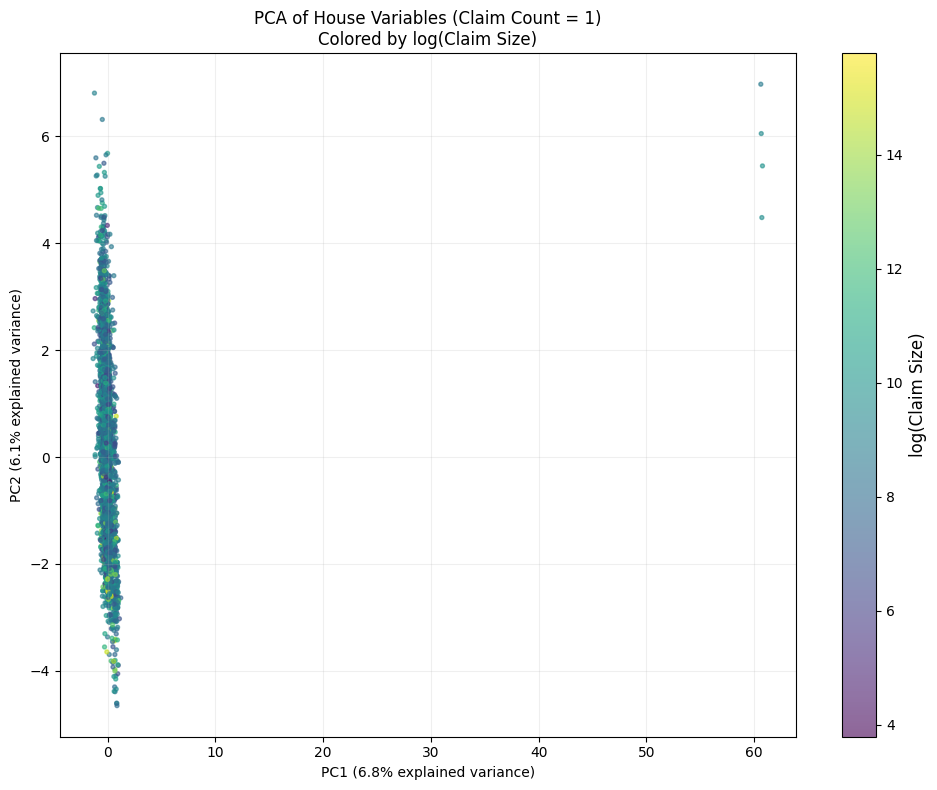

In [3]:
X = data_claim1[house_vars]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

claim_size_log = np.log(data_claim1['CLAIM_SIZE_INDEX'])


### Making the plot ###
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=claim_size_log,
    cmap='viridis',
    alpha=0.6,
    s=8
)

cbar = plt.colorbar(scatter)
cbar.set_label('log(Claim Size)', fontsize=12)

plt.xlabel(
    f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% explained variance)'
)

plt.ylabel(
    f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% explained variance)'
)

plt.title(
    'PCA of House Variables (Claim Count = 1)\nColored by log(Claim Size)'
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [6]:
PC_values = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=house_vars
)

PC_values["PC1_abs"] = PC_values["PC1"].abs()

PC_values.sort_values(
    "PC1_abs",
    ascending=False
)[["PC1"]].head(20)

,PC1
ROOF_TYPE_CAT_Unknown,0.561551
OUTER_WALLS_CAT_Unknown,0.561551
HEATING_TYPE_CAT_Unknown,0.561551
WETROOMS,-0.133775
RESIDENTIAL_AREA,-0.120507
OUTER_WALLS_CAT_Brick_Walls,-0.105549
ROOF_TYPE_CAT_Brick,-0.043741
BASEMENT_AREA,-0.043591
OUTER_WALLS_CAT_Wood_Cladding,0.033754
OUTER_WALLS_CAT_Lightweight_Concrete,0.031783


In [7]:
PC_values["PC2_abs"] = PC_values["PC2"].abs()

PC_values.sort_values(
    "PC2_abs",
    ascending=False
)[["PC2"]].head(20)

,PC2
WATER_SUPPLY_TYPE_CAT_Public_Water_Supply,0.451236
WATER_SUPPLY_TYPE_CAT_Private_Water_Supply,-0.416218
HOUDEN10KM,0.380413
HEATING_TYPE_CAT_District_Heating,0.287867
ROOF_TYPE_CAT_Fiber_Cement_Asbestos,-0.218986
ROOF_TYPE_CAT_Brick,0.213449
BASEMENT_AREA,0.212924
WETROOMS,0.183013
CONSTRUCTION_YEAR,0.181682
FLOORS,0.176899


## Clustering with K-means

We try clustering with k-means deciding on two clusteres to see how it divides

Number of observations: 4987
Number of house variables: 48
Silhouette score: 0.094

Cluster sizes:
cluster
0    2129
1    2858
Name: count, dtype: int64


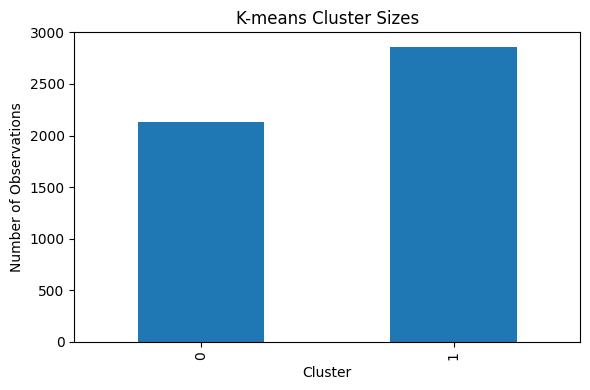

cluster,0,1,abs_difference
BASEMENT_AREA,22.287459,14.039188,8.248271
HOUDEN10KM,11.720808,5.212421,6.508387
RESIDENTIAL_AREA,151.118835,155.825052,4.706217
CONSTRUCTION_YEAR,1967.400658,1962.800560,4.600098
WATER_SUPPLY_TYPE_CAT_Public_Water_Supply,0.999061,0.000000,0.999061
WATER_SUPPLY_TYPE_CAT_Private_Water_Supply,0.000939,0.950315,0.949375
HEATING_TYPE_CAT_District_Heating,0.447628,0.286214,0.161414
BUILDINGS,1.847816,2.008397,0.160582
WETROOMS,4.000939,3.913926,0.087014
ROOF_TYPE_CAT_Brick,0.277595,0.190693,0.086902


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt


data_claim1 = data_mice_encoded[
    data_mice_encoded['CLAIM_COUNT'] == 1
].copy()

print("Number of observations:", len(data_claim1))


house_vars = [
    c for c in data_claim1.columns
    if c not in [
        'POLICY',
        'YEAR',
        'EXPOSURE',
        'CLAIM_COUNT',
        'CLAIM_SIZE',
        'CLAIM_SIZE_INDEX',
        'DEDUCTIBLE',
        'ROOF_TYPE',
        'WATER_SUPPLY_TYPE',
        'HEATING_TYPE',
        'OUTER_WALLS'
    ]
]

print("Number of house variables:", len(house_vars))


X = data_claim1[house_vars]

X_scaled = StandardScaler().fit_transform(X)


kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

data_claim1["cluster"] = clusters

sil_score = silhouette_score(X_scaled, clusters)

print("Silhouette score:", round(sil_score, 3))


cluster_counts = data_claim1["cluster"].value_counts().sort_index()

print("\nCluster sizes:")
print(cluster_counts)

plt.figure(figsize=(6, 4))
cluster_counts.plot(kind="bar")

plt.xlabel("Cluster")
plt.ylabel("Number of Observations")
plt.title("K-means Cluster Sizes")

plt.tight_layout()
plt.show()


summary = data_claim1[house_vars + ["cluster"]].groupby("cluster").mean().T

summary["abs_difference"] = (
    summary[1] - summary[0]
).abs()

summary = summary.sort_values(
    "abs_difference",
    ascending=False
)

display(summary.head(20))

### K-means clustering on PCA

Silhouette score: 0.094


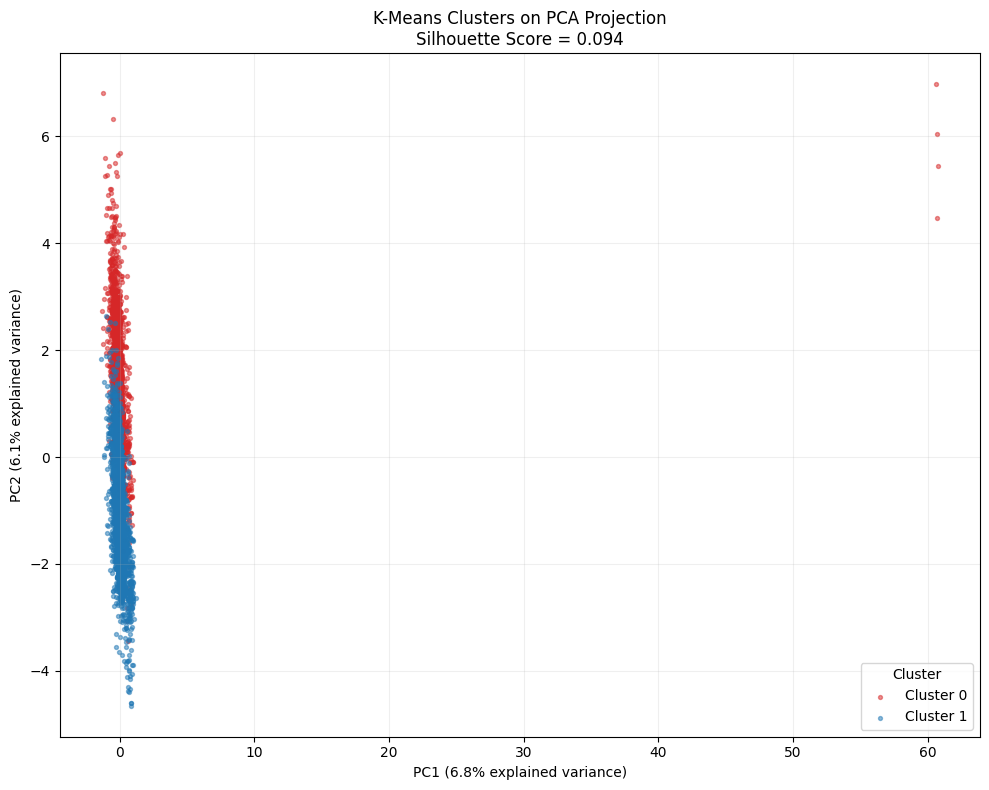

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


data_claim1 = data_mice_encoded[
    data_mice_encoded['CLAIM_COUNT'] == 1
].copy()


house_vars = [
    c for c in data_claim1.columns
    if c not in [
        'POLICY',
        'YEAR',
        'EXPOSURE',
        'CLAIM_COUNT',
        'CLAIM_SIZE',
        'CLAIM_SIZE_INDEX',
        'DEDUCTIBLE',
        'ROOF_TYPE',
        'WATER_SUPPLY_TYPE',
        'HEATING_TYPE',
        'OUTER_WALLS'
    ]
]

X = data_claim1[house_vars]

X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, clusters)

print("Silhouette score:", round(sil, 3))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))

colors = {
    0: "tab:red",
    1: "tab:blue"
}

for cluster in [0, 1]:
    idx = clusters == cluster

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        c=colors[cluster],
        s=8,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% explained variance)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% explained variance)"
)

plt.title(
    f"K-Means Clusters on PCA Projection\nSilhouette Score = {sil:.3f}"
)

plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()